In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("healthcare_patient_records.csv")

In [4]:
df.head()

,Patient_ID,First_Name,Last_Name,Gender,Date_of_Birth,Age,Blood_Type,Height_cm,Weight_kg,BMI,...,Discharge_Date,Length_of_Stay_Days,Admission_Type,Diagnosis,Medication,Test_Results,Attending_Doctor,Hospital,Insurance_Provider,Billing_Amount_KES
0,PT100000,Susan,Otieno,Female,2018-08-14,8,A+,176.0,64.0,20.7,...,2025-09-08,6,Urgent,Urinary Tract Infection,Amoxicillin,Abnormal,Dr. Grace Rono,Coptic Hospital,Britam,32049.0
1,PT100001,Otieno,Odhiambo,Male,1936-05-12,90,A+,152.0,62.0,26.8,...,2023-05-27,5,Urgent,Coronary Artery Disease,Insulin Glargine,Normal,Dr. Aisha Waweru,Kikuyu Mission Hospital,NHIF/SHA,19140.0
2,PT100002,Njeri,Miller,Female,1976-12-27,49,A+,171.0,67.0,22.9,...,2023-08-30,7,Elective,Obesity,Ciprofloxacin,Normal,Dr. Esther Rono,Moi Teaching and Referral Hospital,Madison Insurance,36029.0
3,PT100003,Linda,Korir,Female,1932-04-15,94,O+,165.0,74.0,27.2,...,2023-07-13,10,Emergency,Coronary Artery Disease,Amoxicillin,Normal,Dr. Victor Gitau,Mater Misericordiae Hospital,NHIF/SHA,23238.0
4,PT100004,Kevin,Korir,Male,1987-07-17,39,B+,189.0,49.0,13.7,...,2025-09-16,3,Emergency,Pneumonia,Lisinopril,Normal,Dr. Faith Gitau,Gertrude's Children's Hospital,UAP Old Mutual,12506.0


In [7]:
df.shape

(10015, 24)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           10015 non-null  object 
 1   First_Name           10015 non-null  object 
 2   Last_Name            10015 non-null  object 
 3   Gender               10015 non-null  object 
 4   Date_of_Birth        10015 non-null  object 
 5   Age                  10015 non-null  int64  
 6   Blood_Type           10015 non-null  object 
 7   Height_cm            10015 non-null  float64
 8   Weight_kg            10015 non-null  float64
 9   BMI                  10015 non-null  float64
 10  Smoker               10015 non-null  object 
 11  Alcohol_Use          10015 non-null  object 
 12  Chronic_Condition    10015 non-null  object 
 13  Admission_Date       10015 non-null  object 
 14  Discharge_Date       10015 non-null  object 
 15  Length_of_Stay_Days  10015 non-null 

In [9]:
df.isnull().sum()

Patient_ID               0
First_Name               0
Last_Name                0
Gender                   0
Date_of_Birth            0
Age                      0
Blood_Type               0
Height_cm                0
Weight_kg                0
BMI                      0
Smoker                   0
Alcohol_Use              0
Chronic_Condition        0
Admission_Date           0
Discharge_Date           0
Length_of_Stay_Days      0
Admission_Type           0
Diagnosis                0
Medication             672
Test_Results           300
Attending_Doctor         0
Hospital                 0
Insurance_Provider     200
Billing_Amount_KES       0
dtype: int64

In [22]:
df["Medication"] = df["Medication"].fillna("Unknown")

df["Test_Results"] = df["Test_Results"].fillna("Unknown")

df["Insurance_Provider"] = df["Insurance_Provider"].fillna("Unknown")

In [23]:
df.isnull().sum()

Patient_ID             0
First_Name             0
Last_Name              0
Gender                 0
Date_of_Birth          0
Age                    0
Blood_Type             0
Height_cm              0
Weight_kg              0
BMI                    0
Smoker                 0
Alcohol_Use            0
Chronic_Condition      0
Admission_Date         0
Discharge_Date         0
Length_of_Stay_Days    0
Admission_Type         0
Diagnosis              0
Medication             0
Test_Results           0
Attending_Doctor       0
Hospital               0
Insurance_Provider     0
Billing_Amount_KES     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(15)

In [11]:
df[df.duplicated()]

,Patient_ID,First_Name,Last_Name,Gender,Date_of_Birth,Age,Blood_Type,Height_cm,Weight_kg,BMI,...,Discharge_Date,Length_of_Stay_Days,Admission_Type,Diagnosis,Medication,Test_Results,Attending_Doctor,Hospital,Insurance_Provider,Billing_Amount_KES
10000,PT103797,Adhiambo,Njoroge,Female,1953-12-05,72,O-,174.0,80.0,26.4,...,2024-09-21,14,Urgent,Allergic Reaction,Ciprofloxacin,Normal,Dr. Faith Mutua,Kenyatta National Hospital,Britam,33364.0
10001,PT105906,Susan,Kiprotich,Female,1983-05-22,43,O+,157.0,89.0,36.1,...,2024-05-06,2,Elective,Gastroenteritis,Metformin,Abnormal,Dr. Victor Ndegwa,Aga Khan University Hospital,APA Insurance,22843.0
10002,PT102007,Njoroge,Kiprotich,Male,1955-02-25,71,AB+,162.0,65.0,24.8,...,2024-12-08,0,Urgent,Anemia,Prednisone,Abnormal,Dr. Michael Gitau,MP Shah Hospital,Britam,500.0
10003,PT105313,Emily,Johnson,Female,1986-11-20,39,O+,145.0,79.0,37.6,...,2025-05-04,5,Emergency,Osteoarthritis,Omeprazole,Normal,Dr. Brian Achola,Aga Khan University Hospital,AAR Insurance,20399.0
10004,PT100905,Wambui,Williams,Female,1984-02-03,42,O+,155.0,112.0,46.6,...,2026-03-19,5,Routine Checkup,HIV/AIDS Management,Prednisone,Normal,Dr. Peter Ndegwa,Mater Misericordiae Hospital,NHIF/SHA,18809.0
10005,PT102718,Kiptoo,Garcia,Male,1997-07-26,29,O+,158.0,79.0,31.6,...,2024-03-25,1,Urgent,Hypertension,Ibuprofen,Normal,Dr. Faith Gitau,Kikuyu Mission Hospital,NHIF/SHA,13804.0
10006,PT102035,Akinyi,Cherono,Female,1993-05-02,33,A+,180.0,52.0,16.0,...,2023-03-26,1,Urgent,Fracture,Atorvastatin,Inconclusive,Dr. Samuel Ndegwa,Gertrude's Children's Hospital,Resolution Insurance,8489.0
10007,PT106989,George,Brown,Male,2019-04-13,7,B+,161.0,76.0,29.3,...,2025-11-11,4,Elective,Urinary Tract Infection,Ciprofloxacin,Abnormal,Dr. Peter Ndegwa,Karen Hospital,NHIF/SHA,14903.0
10008,PT103769,Ashley,Hernandez,Female,2002-09-25,23,B+,148.0,72.0,32.9,...,2026-08-17,3,Emergency,Migraine,Ibuprofen,Inconclusive,Dr. Victor Cheruiyot,Gertrude's Children's Hospital,Madison Insurance,18120.0
10009,PT104382,Thomas,Hernandez,Male,1945-04-29,81,AB+,155.0,49.0,20.4,...,2026-05-21,2,Elective,Coronary Artery Disease,NaN,Normal,Dr. Peter Achola,Mater Misericordiae Hospital,NHIF/SHA,9521.0


In [20]:
df = df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Length_of_Stay_Days,Billing_Amount_KES
count,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000,10015.000000
mean,47.095257,164.884773,70.099251,26.079780,3.766350,17261.596805
std,27.198538,10.028037,15.067021,6.530436,4.654867,14045.288744
min,0.000000,127.000000,13.000000,4.800000,0.000000,500.000000
25%,24.000000,158.000000,60.000000,21.500000,1.000000,8567.500000
50%,47.000000,165.000000,70.000000,25.700000,3.000000,14109.000000
75%,71.000000,172.000000,80.000000,30.100000,5.000000,21341.000000
max,94.000000,205.000000,127.000000,54.300000,30.000000,124983.000000


In [13]:
df["Gender"].value_counts()

Gender
Female    5088
Male      4927
Name: count, dtype: int64

In [14]:
df["Blood_Type"].value_counts()

Blood_Type
O+     3858
A+     3349
B+      872
O-      725
A-      600
AB+     301
B-      206
AB-     104
Name: count, dtype: int64

In [15]:
df["Admission_Type"].value_counts()

Admission_Type
Elective           3523
Emergency          3009
Urgent             2027
Routine Checkup    1456
Name: count, dtype: int64

In [27]:
df["Diagnosis"].value_counts()

Diagnosis
Anemia                     410
Gastroenteritis            405
Hyperlipidemia             404
Coronary Artery Disease    402
Chronic Kidney Disease     401
COPD                       396
Fracture                   393
Obesity                    389
Allergic Reaction          388
Urinary Tract Infection    387
Asthma                     387
Malaria                    386
Peptic Ulcer Disease       384
Pneumonia                  384
Appendicitis               382
Tuberculosis               381
Anxiety Disorder           381
Type 2 Diabetes            381
Skin Infection             377
Stroke                     377
Migraine                   376
Depression                 376
HIV/AIDS Management        373
Osteoarthritis             372
Typhoid Fever              366
Hypertension               342
Name: count, dtype: int64

In [26]:
df["Hospital"].value_counts()

Hospital
Mater Misericordiae Hospital          1040
Coptic Hospital                       1033
Karen Hospital                        1028
Kenyatta National Hospital            1022
Aga Khan University Hospital           992
Gertrude's Children's Hospital         990
MP Shah Hospital                       986
Nairobi Hospital                       982
Kikuyu Mission Hospital                969
Moi Teaching and Referral Hospital     958
Name: count, dtype: int64

In [24]:
df["Test_Results"].value_counts()

Test_Results
Normal          5386
Abnormal        3391
Inconclusive     923
Unknown          300
Name: count, dtype: int64

In [25]:
df["Insurance_Provider"].value_counts()

Insurance_Provider
NHIF/SHA                2943
AAR Insurance           1204
Britam                   976
Jubilee Insurance        948
Self-Pay                 830
CIC Insurance            775
Madison Insurance        671
APA Insurance            667
Resolution Insurance     397
UAP Old Mutual           389
Unknown                  200
Name: count, dtype: int64

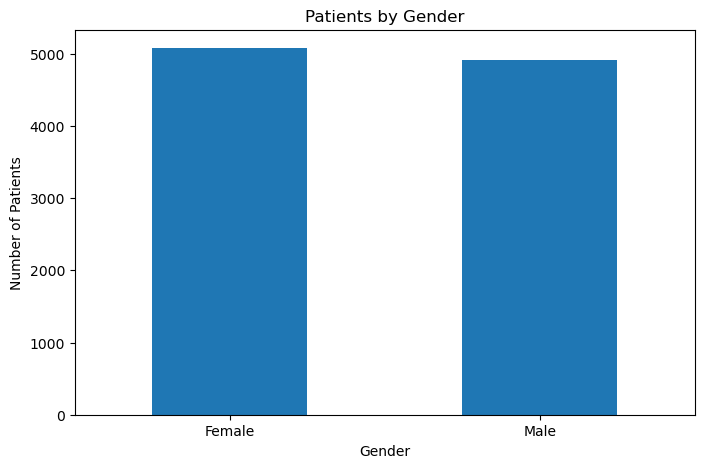

In [28]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(8,5))

gender_counts.plot(kind="bar")

plt.title("Patients by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.xticks(rotation=0)
plt.show()

In [29]:
#DIAGNOSIS ANALYSIS
diagnosis_counts = df["Diagnosis"].value_counts()

print(diagnosis_counts)

Diagnosis
Anemia                     410
Gastroenteritis            405
Hyperlipidemia             404
Coronary Artery Disease    402
Chronic Kidney Disease     401
COPD                       396
Fracture                   393
Obesity                    389
Allergic Reaction          388
Urinary Tract Infection    387
Asthma                     387
Malaria                    386
Peptic Ulcer Disease       384
Pneumonia                  384
Appendicitis               382
Tuberculosis               381
Anxiety Disorder           381
Type 2 Diabetes            381
Skin Infection             377
Stroke                     377
Migraine                   376
Depression                 376
HIV/AIDS Management        373
Osteoarthritis             372
Typhoid Fever              366
Hypertension               342
Name: count, dtype: int64


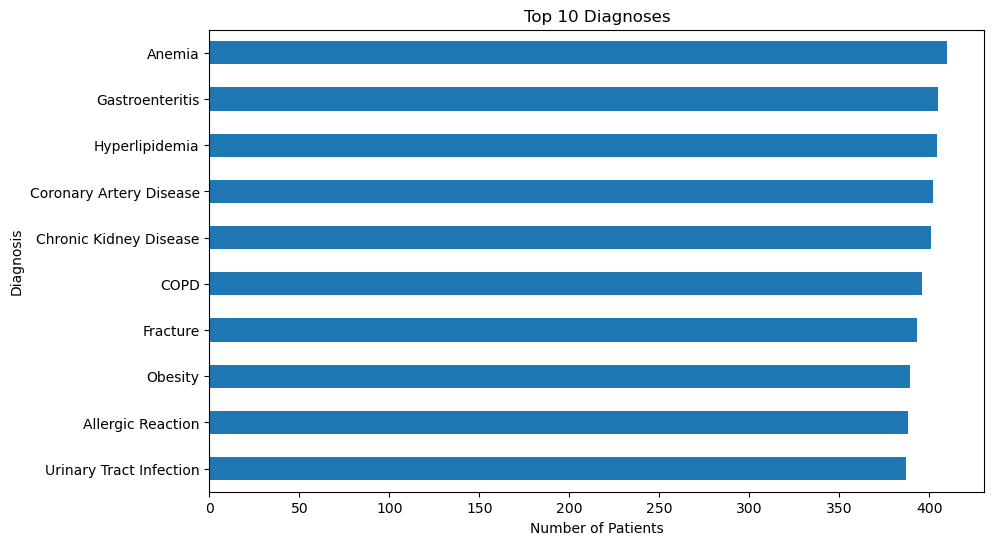

In [30]:
top_diagnoses = df["Diagnosis"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_diagnoses.sort_values().plot(kind="barh")

plt.title("Top 10 Diagnoses")
plt.xlabel("Number of Patients")
plt.ylabel("Diagnosis")

plt.show()

In [31]:
#HOSPITAL ANALYSIS
hospital_counts = df["Hospital"].value_counts()

print(hospital_counts)

Hospital
Mater Misericordiae Hospital          1040
Coptic Hospital                       1033
Karen Hospital                        1028
Kenyatta National Hospital            1022
Aga Khan University Hospital           992
Gertrude's Children's Hospital         990
MP Shah Hospital                       986
Nairobi Hospital                       982
Kikuyu Mission Hospital                969
Moi Teaching and Referral Hospital     958
Name: count, dtype: int64


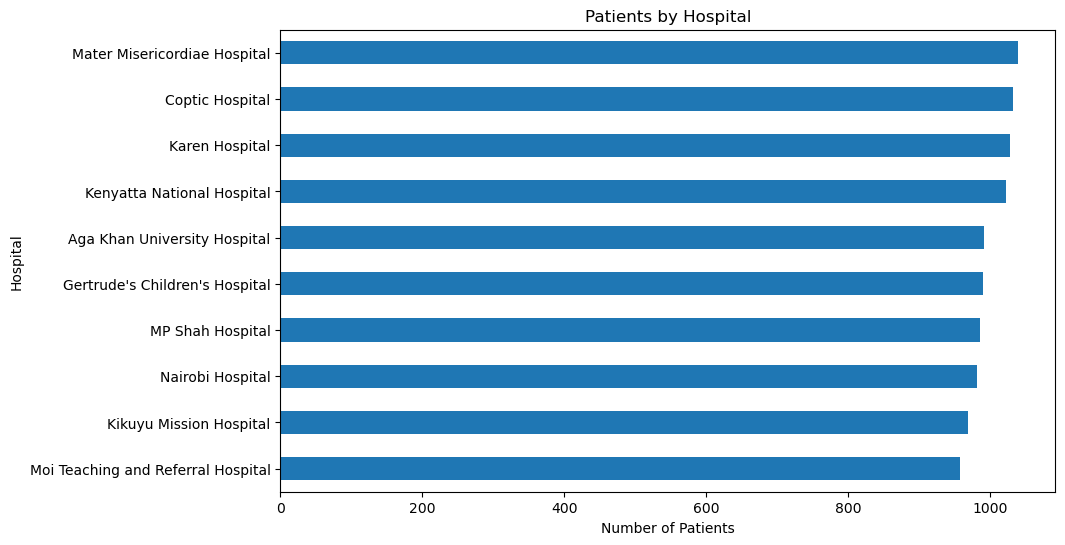

In [32]:
plt.figure(figsize=(10,6))

hospital_counts.sort_values().plot(kind="barh")

plt.title("Patients by Hospital")
plt.xlabel("Number of Patients")
plt.ylabel("Hospital")

plt.show()

In [33]:
#BILLING ANALSYSIS
total_billing = df["Billing_Amount_KES"].sum()

print(f"Total Billing: KES {total_billing:,.2f}")

Total Billing: KES 172,668,300.00


In [34]:
average_billing = df["Billing_Amount_KES"].mean()

print(f"Average Billing: KES {average_billing:,.2f}")

Average Billing: KES 17,266.83


In [35]:
max_billing = df["Billing_Amount_KES"].max()

print(f"Maximum Billing: KES {max_billing:,.2f}")

Maximum Billing: KES 124,983.00


In [36]:
min_billing = df["Billing_Amount_KES"].min()

print(f"Minimum Billing: KES {min_billing:,.2f}")

Minimum Billing: KES 500.00


In [37]:
pip install streamlit pandas matplotlib

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.1
    Uninstalling protobuf-7.35.1:
      Successfully uninstalled protobuf-7.35.1
Note: you may need to restart the kernel to use updated packages.
